In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class AgentState(TypedDict):
    number1:int
    number2:int
    number3:int
    number4:int
    operation1:str
    operation2:str
    result1:int
    result2:int
    

In [3]:
def adder1(state:AgentState)->AgentState:
    state['result1']=state['number1']+state['number2']
    return state

def subtractor1(state:AgentState)->AgentState:
    state['result1']=state['number1']-state['number2']
    return state
    
def adder2(state:AgentState)->AgentState:
    state['result2']=state['number3']+state['number4']
    return state

def subtractor2(state:AgentState)->AgentState:
    state['result2']=state['number3']-state['number4']
    return state

def choose_next_node1(state:AgentState)->str:
    if(state['operation1']=="+"):
        return "add1"
    else:
        return "sub1"

def choose_next_node2(state:AgentState)->str:
    if(state['operation2']=="+"):
        return "add2"
    else:
        return "sub2"

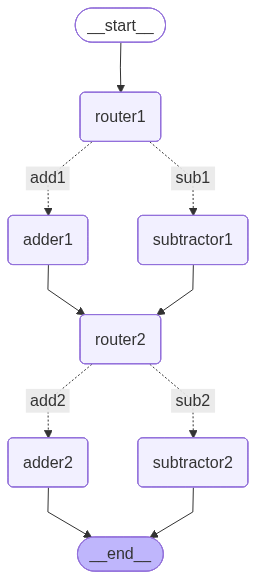

In [9]:
graph=StateGraph(AgentState)
graph.add_node("adder1", adder1)
graph.add_node("subtractor1", subtractor1)
graph.add_node("adder2", adder2)
graph.add_node("subtractor2", subtractor2)
graph.add_node("router1", lambda state:state)
graph.add_node("router2", lambda state:state)


graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    choose_next_node1,
    {
        "add1":"adder1",
        "sub1":"subtractor1"
    }
)

graph.add_edge("adder1", "router2")
graph.add_edge("subtractor1", "router2")
graph.add_conditional_edges(
    "router2",
    choose_next_node2,
    {
        "add2":"adder2",
        "sub2":"subtractor2"
    }
)
graph.add_edge("adder2", END)
graph.add_edge("subtractor2", END)

bot = graph.compile()
bot

